# Programming Assignment 2: Linear Regression

Split the samples into 60% training, 20% validation, and 20% testing data at random
* The code divides the dataset into three parts: training, validation, and testing* 
ensures that the model is trained on a sufficient portion of the data, validated on a separate portion to tune its performance, and finally tested on a completely unseen portion to evaluate its real-world accuracy. random_state=42 ensures consistent splits across different runs.

Validation MSE: 9.964418645297126
Test MSE: 7.763227282508085


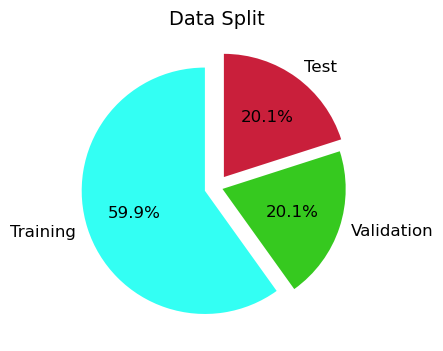

In [7]:
!pip install openpyxl
!pip install colorama

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Load the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx'
data = pd.read_excel(url)
X = data[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]  # Features
y = data['Y1']  # Target (Heating Load)

# 2. Split the data
# First split into train and remaining (validation + test)
X_train, X_rem, y_train, y_rem = train_test_split(X, y, test_size=0.4, random_state=42)
# Then split the remaining into validation and test
X_valid, X_test, y_valid, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42)

# 3. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate the model on the validation set
y_pred = model.predict(X_valid)
mse = mean_squared_error(y_valid, y_pred)
print(f"Validation MSE: {mse}")

# 5. Evaluate the model on the test set
y_test_pred = model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {test_mse}")

# 6. Visualization: 2D Pie chart of data splits
# Pie charts are inherently 2D and are not suitable for 3D projection
sizes = [len(X_train), len(X_valid), len(X_test)]
labels = ['Training', 'Validation', 'Test']
colors = ['#33fff3', '#36c91f', '#c91f3b']

fig, ax = plt.subplots(figsize=(4, 4))  # Create a 2D subplot

# Explode the slices slightly for better visibility
explode = (0.1, 0.05, 0.1)

ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
       explode=explode, textprops={'fontsize': 12})

ax.set_title('Data Split', fontsize=14)

plt.show()

* Using Ridge regularization, find different choices of regularization parameters

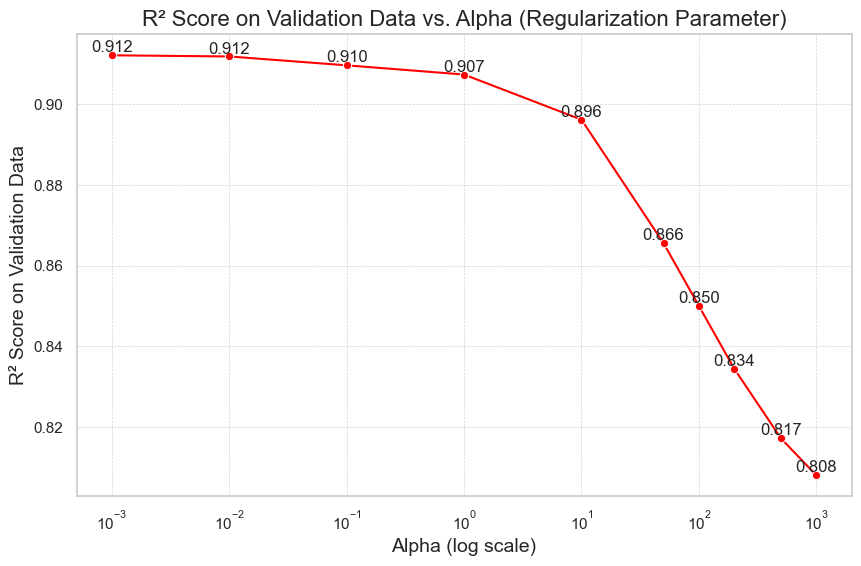

Best alpha: 0.001


In [13]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Assume X and y are your feature and target datasets
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define 10 different Ridge regularization parameters (alpha values)
alphas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
validation_r2_scores = []

# Loop over each alpha and train the model, evaluate on validation data
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_val_pred = ridge.predict(X_val)
    r2 = r2_score(y_val, y_val_pred)
    validation_r2_scores.append(r2)

# Visualization: Plot R² scores for different regularization parameters
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Change line color to red
sns.lineplot(x=alphas, y=validation_r2_scores, marker='o', color='red')

plt.xscale('log')
plt.title('R² Score on Validation Data vs. Alpha (Regularization Parameter)', fontsize=16)
plt.xlabel('Alpha (log scale)', fontsize=14)
plt.ylabel('R² Score on Validation Data', fontsize=14)

# Customize grid color to a shade of gray that complements red
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)

# Add data point labels
for i, alpha in enumerate(alphas):
    plt.text(alpha, validation_r2_scores[i], f'{validation_r2_scores[i]:.3f}', ha='center', va='bottom')

plt.show()

# Best alpha
best_alpha = alphas[validation_r2_scores.index(max(validation_r2_scores))]
print(f'Best alpha: {best_alpha}')


* Final Evaluation

In [25]:
# Train the Ridge model using the best alpha on the combined training and validation sets
import numpy as np
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

# Evaluate the best model on the test set
y_test_pred = best_ridge.predict(X_test)

# Metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_nmse = test_mse / np.var(y_test)  # Normalized Mean Squared Error

# Print performance metrics
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test NMSE: {test_nmse:.4f}")

Test R² Score: 0.9200
Test MSE: 7.8594
Test NMSE: 0.0800


* Identify the best model’s coefficients, intercept, and accuracies (R² scores) for training, validation, and test sets.

In [27]:
# Coefficients and intercept of the best model
print('Coefficients:', best_ridge.coef_)
print('Intercept:', best_ridge.intercept_)

# R² score for training and validation sets
train_r2 = best_ridge.score(X_train, y_train)
val_r2 = best_ridge.score(X_val, y_val)

print(f'R² on training set: {train_r2}')
print(f'R² on validation set: {val_r2}')
print(f'R² on test set: {test_r2}')

# Visualization: Coefficients of the model with enhancements
import numpy as np  # Import numpy and assign it the alias 'np'
coefficients = pd.Series(best_ridge.coef_, index=X.columns)
plt.figure(figsize=(10, 6))

# Create a color palette with distinct colors
colors = sns.color_palette("viridis", len(coefficients))

# Sort coefficients by absolute value for better visualization
coefficients = coefficients.abs().sort_values() #Get absolute values and sort



Coefficients: [-6.39877083e+01 -6.16163181e-02  3.60960982e-02 -4.88564236e-02
  4.18642370e+00 -2.33301840e-02  1.99312030e+01  2.03804780e-01]
Intercept: 82.58265863787004
R² on training set: 0.9170042698556776
R² on validation set: 0.9127324286109813
R² on test set: 0.9200218772718116


<Figure size 1000x600 with 0 Axes>

## Top 5 features

Top 5 features: ['X1', 'X7', 'X5', 'X8', 'X2']


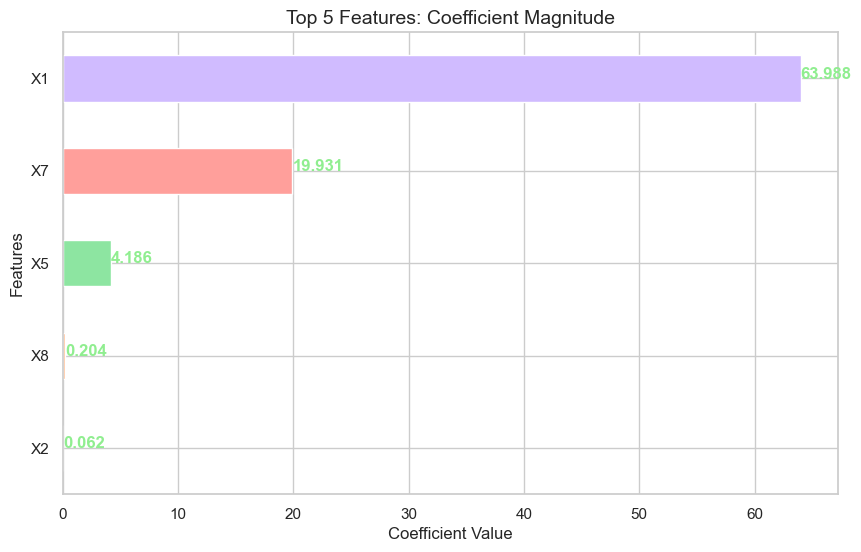

In [45]:
# Obtain the top 5 features
top_5_features = coefficients.abs().nlargest(5)
print('Top 5 features:', top_5_features.index.tolist())

# Visualization
plt.figure(figsize=(10, 6))

# Generate a distinct color for each bar
colors = sns.color_palette('pastel', len(top_5_features))

# Create the horizontal bar plot
ax = top_5_features.sort_values().plot(kind='barh', color=colors)

plt.title('Top 5 Features: Coefficient Magnitude', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Add value labels to each bar
for i, v in enumerate(top_5_features.sort_values()):
    ax.text(v + 0.01, i, str(round(v, 3)), color='lightgreen', fontweight='bold')

plt.show()

* Procedure using the top 5 features

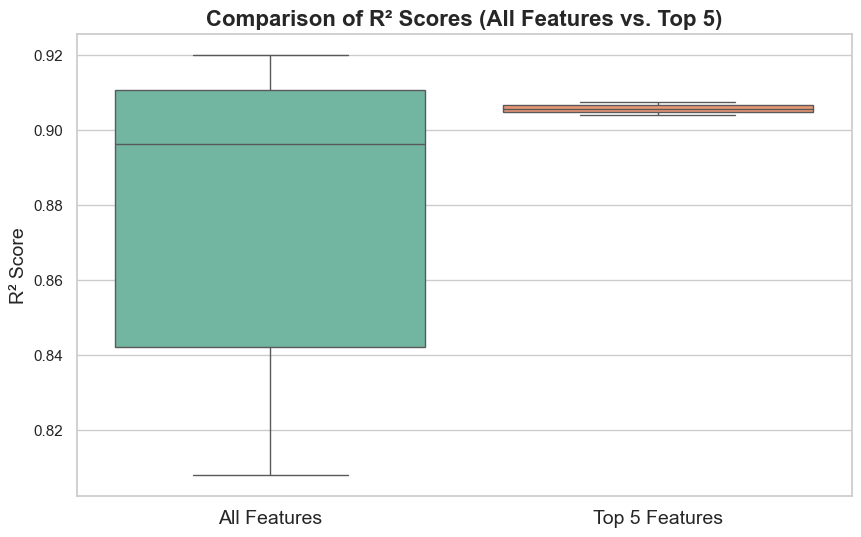

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Assuming you've already computed these values earlier:
# - validation_r2_scores: R² scores for validation with all features
# - test_r2: R² score for test set with all features
# - best_alpha: best alpha determined from your original code
# - X_train, X_val, X_test, y_train, y_val, y_test are already defined

# Define 10 different Ridge regularization parameters (alpha values)
alphas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
validation_r2_scores = []

# Loop over each alpha and train the model, evaluate on validation data
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_val_pred = ridge.predict(X_val)
    r2 = r2_score(y_val, y_val_pred)
    validation_r2_scores.append(r2)

# Train the model with the best alpha from your original code
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train, y_train)

# Predictions on the test set with all features
y_test_pred = ridge_best.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)

# Select the top 5 features based on previous analysis (modify as needed)
# For this example, I am assuming `top_5_features.index` is a list of indices of the top 5 features
X_top_5_train = X_train[top_5_features.index]
X_top_5_val = X_val[top_5_features.index]
X_top_5_test = X_test[top_5_features.index]

# Retrain the model using the top 5 features
ridge_top_5 = Ridge(alpha=best_alpha)
ridge_top_5.fit(X_top_5_train, y_train)

# Evaluate on validation and test sets
y_top_5_val_pred = ridge_top_5.predict(X_top_5_val)
y_top_5_test_pred = ridge_top_5.predict(X_top_5_test)

val_r2_top_5 = r2_score(y_val, y_top_5_val_pred)
test_r2_top_5 = r2_score(y_test, y_top_5_test_pred)

# Box plot: Create lists of R² scores for both models
all_features_r2 = validation_r2_scores + [test_r2]  # R² scores for validation and test with all features
top_5_r2 = [val_r2_top_5, test_r2_top_5]  # R² scores for validation and test with top 5 features

# Prepare the data for boxplot
data = [all_features_r2, top_5_r2]

# Plotting the boxplot
plt.figure(figsize=(10, 6))

# Create the boxplot with two categories: All Features and Top 5 Features
sns.boxplot(data=data, palette="Set2")

# Set the labels for the x-axis
plt.xticks([0, 1], ['All Features', 'Top 5 Features'], fontsize=14)

# Set labels and title
plt.title('Comparison of R² Scores (All Features vs. Top 5)', fontsize=16, fontweight='bold')
plt.ylabel('R² Score', fontsize=14)

# Show plot
plt.show()


# Guided Questions:

**What is the impact of removing certain features on the model’s performance?**

Eliminating specific features can notably affect the model's performance. If important features with high coefficients are removed, the model's predictive capability may decrease, leading to lower R² scores and higher errors in metrics like MSE and NMSE. However, removing less critical features can help simplify the model, making it more interpretable, often without causing significant harm to its performance.


**Why is it necessary to split the data into training, validation, and testing sets? What could happen if this step is skipped?**

Splitting the data into training, validation, and testing sets is important because it helps the model learn general patterns instead of just memorizing the training data. If we skip this step, the model might overfit, meaning it performs well on the training data but fails on new, unseen data. It also becomes harder to fine-tune the model and check its true performance. Without this split, the model may not work well in real-world situations.

 **How can the generalization ability of the model be assessed using the test data? What steps would you take to ensure the model generalizes well to unseen data?**

One way to evaluate the model’s ability to generalize is by testing it on data it hasn’t seen before. The test set provides an indication of how the model will perform in real-world situations. To improve generalization, it's essential to properly split the data into training, validation, and test sets. Cross-validation can also help check if the model consistently performs well across different subsets of data. Techniques like regularization (e.g., Ridge) can prevent overfitting, while monitoring both training and validation performance helps detect overfitting. Finally, testing on unseen data helps simulate the model's real-world effectiveness.